# Employee Attrition Prediction & Workforce Risk Analysis

## Final Project Report

**Student:** Anusha Pala

**Problem ID:** P1 - Employee Attrition Prediction & Workforce Risk Analysis (IT / BFSI / Healthcare / Manufacturing / Retail)

---

## Contents

1. Problem Statement and Objective
2. Dataset Description
3. Data Preparation and Feature Engineering
4. Exploratory Data Analysis
5. Model Comparison: Baseline vs Improved Models
6. Hyperparameter Tuning
7. Evaluation Metrics
8. Discussion and Learnings

# 1. Problem Statement and Objective

## 1.1 Organisational Context and Motivation

Employee attrition extends beyond an isolated human resources concern, directly affecting organisational productivity, operational continuity and recruitment costs. When an experienced employee departs, the following consequences typically arise:

- **Productivity:** the departing employee takes institutional knowledge with them, disrupting ongoing work.
- **Continuity:** remaining teams require time to adjust and recover normal functioning.
- **Cost:** replacing an employee, accounting for hiring, training and lost productivity, is commonly estimated at between half and twice that employee's annual salary.

If an organisation can identify employees at elevated risk of leaving before they resign, timely interventions become possible, such as a conversation with the reporting manager, a compensation review, or a change in role. This capability forms the central motivation for the present project.

## 1.2 Objective

The objective of this project is to build a supervised machine learning model that predicts whether an employee is likely to leave the organisation (`Attrition`), using demographic, performance, compensation and engagement-related attributes.

**Target variable:** `Attrition`
- 1 (Yes) -> employee left the company
- 0 (No) -> employee remains with the company

## 1.3 Business Context

Employee attrition has implications beyond simply replacing staff. Unexpected turnover can disrupt ongoing projects, reduce team productivity, increase recruitment and training costs, and lead to the loss of organisational knowledge. Developing a predictive model enables HR teams to identify employees who may be at risk of leaving and intervene before attrition occurs. The objective is therefore not only to build an accurate classifier, but also to provide insights that can support evidence-based workforce planning.

## 1.4 Evaluation Priorities

Attrition datasets are typically imbalanced, with a substantially larger proportion of employees remaining than leaving. In this context, failing to identify an employee who will actually leave (a false negative) carries a higher cost than a false alarm, since a false alarm results only in one additional HR conversation, whereas a missed leaver results in an unplanned hiring cycle. Accordingly, the following evaluation priorities were established prior to model development, in order of importance:

1. Recall on the "Yes" (attrition) class
2. F1-score, as the principal balanced metric
3. ROC-AUC, to assess overall class separability

Accuracy is reported for completeness but is not treated as the primary metric, since with an approximately 84:16 class split, a model that always predicts "No" would already achieve close to 84% accuracy. These priorities are revisited in Section 7 to assess whether the final selected model satisfies them.

# 2. Dataset Description

The IBM HR Analytics Employee Attrition & Performance dataset is a widely used benchmark dataset for employee attrition prediction. It contains employee demographic, organisational, compensation, and workplace-related variables suitable for binary classification.

### Dataset Source

**HR Employee Attrition Dataset**

**Kaggle:** https://www.kaggle.com/datasets/madalinemaryj/hr-employee-attrition-dataset

The dataset was obtained from Kaggle and contains standardised column names together with several additional engineered features, namely **age_group**, **Experience_Group**, **Attrition_flag**, and **Month**. The dataset consists of 1,470 employee records across 39 columns and was loaded using `pandas.read_csv()`.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # fixed once here and reused everywhere below (split, SMOTE, every model) so re-running this notebook gives the same numbers
pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")

df = pd.read_csv("hr dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (1470, 39)


,Age,Attrition,Business_Travel,Daily_Rate,Department,Distance_From_Home,Education,Education_Field,Employee_Count,Employee_Number,Environment_Satisfaction,Gender,Hourly_Rate,Job_Involvement,Job_Level,Job_Role,Job_Satisfaction,Marital_Status,Monthly_Income,Monthly_Rate,NumCompanies_Worked,Over18,Over_Time,Percent_Salary_Hike,Performance_Rating,Relationship_Satisfaction,Standard_Hours,Stock_Option_Level,Total_Working_Years,Training_Times_LastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,age_group,Experience_Group,Attrition_flag,Month
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,36-45,5+,1,Jan-1900
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,45+,5+,0,Jan-1900
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,36-45,0-2,1,Jan-1900
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,25-35,5+,0,Jan-1900
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,25-35,3-5,0,Jan-1900


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1470 non-null   int64 
 1   Attrition                  1470 non-null   object
 2   Business_Travel            1470 non-null   object
 3   Daily_Rate                 1470 non-null   int64 
 4   Department                 1470 non-null   object
 5   Distance_From_Home         1470 non-null   int64 
 6   Education                  1470 non-null   int64 
 7   Education_Field            1470 non-null   object
 8   Employee_Count             1470 non-null   int64 
 9   Employee_Number            1470 non-null   int64 
 10  Environment_Satisfaction   1470 non-null   int64 
 11  Gender                     1470 non-null   object
 12  Hourly_Rate                1470 non-null   int64 
 13  Job_Involvement            1470 non-null   int64 
 14  Job_Leve

In [ ]:
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True).round(3))


Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


Of the 1,470 employees in the dataset, 1,233 (83.9%) remained with the organisation and 237 (16.1%) left, indicating a moderate class imbalance. This imbalance informs several later modelling decisions, including the use of SMOTE, the decision not to rely on accuracy as the primary metric, and the F1/recall priorities established in Section 1.3.

# 3. Data Preparation and Feature Engineering

## 3.1 Data Quality Checks


In [ ]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows (full row):", df.duplicated().sum())


Missing values per column:
Series([], dtype: int64)

Total missing values: 0
Duplicate rows (full row): 0


No missing values or duplicate rows were identified. However, a duplicate-row check is not meaningful while `Employee_Number` (a unique identifier) remains in the dataset, since this column alone guarantees that every row appears unique. A meaningful duplicate check is therefore performed after identifier columns are removed, in the step that follows.

## 3.2 Removing Non-Predictive, Leaky, and Noisy Columns

A column-by-column review using `.unique()` and `.value_counts()` identified several issues that a standard null-value check alone would not reveal:

| Column | Issue Identified | Action Taken |
|---|---|---|
| `Employee_Count` | constant value of 1 | dropped - no variance |
| `Standard_Hours` | constant value of 80 | dropped - no variance |
| `Over18` | constant value of 'Y' | dropped - no variance |
| `Employee_Number` | row-level identifier only | dropped - not a predictive feature |
| `Attrition_flag` | found to be an exact copy of the target (confirmed via cross-tabulation below) | dropped - constitutes target leakage |
| `Month` | 68 distinct placeholder values (e.g. `Jan-1901` through `Mar-1905`) with no correspondence to real data | dropped - appears to be noise rather than genuine information |

The columns `age_group` and `Experience_Group` are binned versions of `Age` and tenure that were already present in the raw dataset. As these do not involve the target variable, they do not constitute leakage and were retained alongside the corresponding original numeric columns, since tree-based models can sometimes extract additional signal from a binned representation.

In [ ]:
columns_to_drop = [
    "Employee_Count",
    "Employee_Number",
    "Over18",
    "Standard_Hours",
    "Attrition_flag",
    "Month",
]
columns_to_drop = [c for c in columns_to_drop if c in df.columns]

# Verify Attrition_flag really is a perfect duplicate of Attrition before dropping it
if "Attrition_flag" in df.columns:
    print(pd.crosstab(df["Attrition_flag"], df["Attrition"]))

df = df.drop(columns=columns_to_drop)
print("\nShape after dropping non-predictive / leakage / noise columns:", df.shape)


Attrition         No  Yes
Attrition_flag           
0               1233    0
1                  0  237

Shape after dropping non-predictive / leakage / noise columns: (1470, 33)


A cross-tabulation confirmed that `Attrition_flag` corresponds exactly to `Attrition` for every record in the dataset. This finding illustrates the value of a column-by-column review rather than a generic null/duplicate check alone, as retaining this column would have provided the model with direct access to the target label.

## 3.3 Target Variable Encoding

In [ ]:
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})
df["Attrition"].value_counts()


,count
Attrition,
0,1233
1,237


## 3.4 Feature Engineering

Several tenure-related numeric columns in the dataset are naturally correlated with one another (years at company, years in current role, years since last promotion, and total working years tend to move together), and certain categorical distinctions can be more informative when simplified to the single factor that matters most. Based on these observations, the following features were engineered:

| Feature | Construction | Rationale |
|---|---|---|
| `TenureRatio` | `YearsAtCompany / (Total_Working_Years + 1)` | An employee who has spent all of their working years at the company differs meaningfully from one who has spent a small fraction of a much longer career there, a distinction `YearsAtCompany` alone does not capture |
| `IncomePerJobLevel` | `Monthly_Income / Job_Level` | Identifies employees who may be underpaid relative to their level, a pattern raw income does not reveal since pay naturally increases with level |
| `PromotionGap` | `YearsSinceLastPromotion / (YearsAtCompany + 1)` | Intended to capture career stagnation, a commonly cited driver of attrition |
| `IsFrequentTraveler` | 1 if Travel_Frequently, else 0 | Simplifies the three-level travel category to the single distinction most relevant to attrition |
| `AvgSatisfaction` | mean of the four satisfaction/work-life balance columns | Consolidates four correlated 1-4 scores into a single composite engagement measure |

The original columns were retained alongside the engineered features rather than replaced, so that models, particularly tree-based ones, can draw on the raw signal where the derived ratio does not fully capture it. The usefulness of these engineered features is examined empirically in the EDA section that follows, and again through feature importance analysis in Section 8.

In [ ]:
df["TenureRatio"] = df["YearsAtCompany"] / (df["Total_Working_Years"] + 1)
df["IncomePerJobLevel"] = df["Monthly_Income"] / df["Job_Level"]
df["PromotionGap"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["IsFrequentTraveler"] = (df["Business_Travel"] == "Travel_Frequently").astype(int)
df["AvgSatisfaction"] = df[["Job_Satisfaction", "Environment_Satisfaction",
                            "Relationship_Satisfaction", "WorkLifeBalance"]].mean(axis=1)

new_features = ["TenureRatio", "IncomePerJobLevel", "PromotionGap", "IsFrequentTraveler", "AvgSatisfaction"]
df[new_features].describe().T


,count,mean,std,min,25%,50%,75%,max
TenureRatio,1470.0,0.581830,0.284476,0.0,0.368421,0.636364,0.833333,0.975610
IncomePerJobLevel,1470.0,2973.800986,770.640517,1009.0,2394.125000,2856.500000,3478.833333,4999.000000
PromotionGap,1470.0,0.236458,0.269358,0.0,0.000000,0.142857,0.428571,0.916667
IsFrequentTraveler,1470.0,0.188435,0.391193,0.0,0.000000,0.000000,0.000000,1.000000
AvgSatisfaction,1470.0,2.730952,0.505815,1.0,2.500000,2.750000,3.000000,4.000000


Categorical encoding of variables such as `Department` and `Job_Role` into numeric form is deliberately deferred until after the EDA section, so that the exploratory plots retain readable category labels (e.g. 'Sales') rather than numeric codes. Encoding is performed immediately prior to the train/test split.

### Summary of Data Preparation

The dataset required relatively little cleaning because it contained no missing values or duplicate records. Most preprocessing therefore focused on identifying features that could unintentionally bias the model, engineering more informative variables, and preparing the data for machine learning algorithms. This ensured that subsequent model evaluation reflected genuine predictive ability rather than artefacts within the dataset.

# 4. Exploratory Data Analysis

## 4.1 Target Distribution


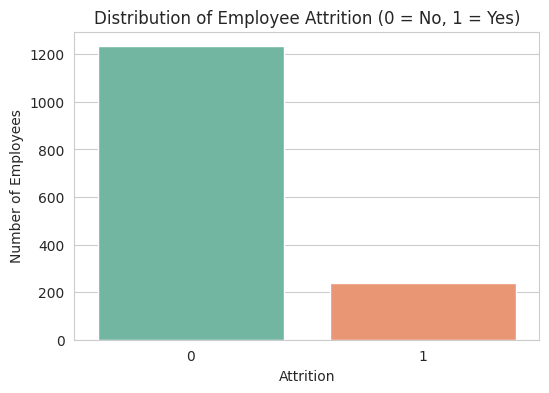

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Attrition", palette="Set2")
plt.title("Distribution of Employee Attrition (0 = No, 1 = Yes)")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()


### Observation: Class Imbalance

The dataset is moderately imbalanced, with employees who stay forming the majority class and employees who leave forming the minority class. In such situations, relying solely on Accuracy can be misleading, since a model that predicts the majority class for every employee would still achieve a relatively high accuracy score.

To address this, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training dataset only. During evaluation, greater emphasis is placed on Precision, Recall, F1-score and ROC-AUC rather than Accuracy.

## 4.2 Numeric Features vs Attrition

Six numeric features were selected for visual comparison against `Attrition`, based on their emergence as strong correlates during initial exploration (Age, income, tenure) or their plausibility as attrition drivers (distance from home, number of prior employers). Visualising all 20+ numeric columns individually would add limited additional insight beyond this subset.

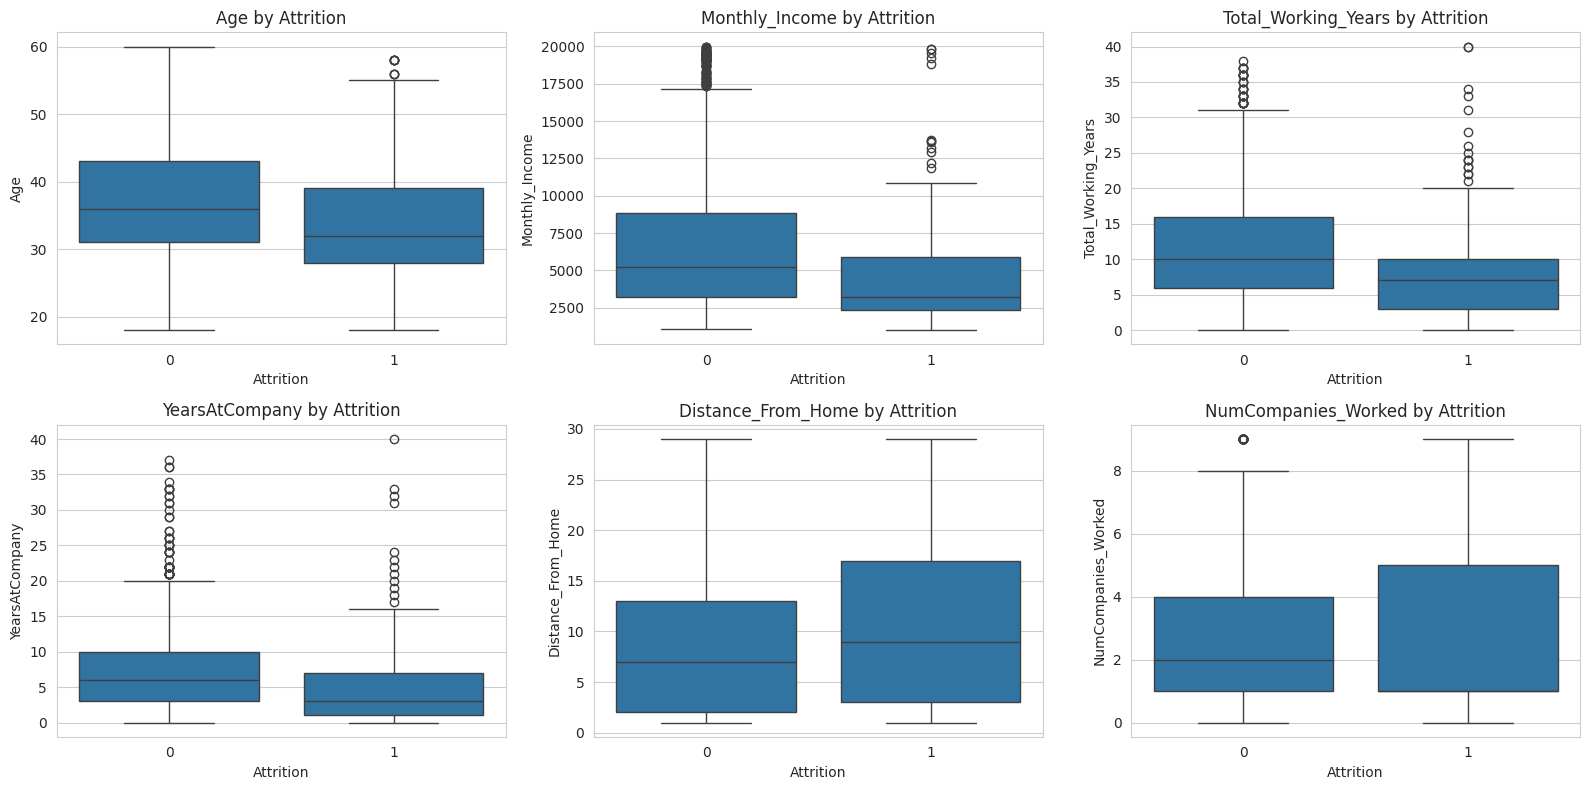

In [ ]:
numerical_features = ["Age", "Monthly_Income", "Total_Working_Years", "YearsAtCompany",
                      "Distance_From_Home", "NumCompanies_Worked"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feature in zip(axes.flatten(), numerical_features):
    sns.boxplot(data=df, x="Attrition", y=feature, ax=ax)
    ax.set_title(f"{feature} by Attrition")
plt.tight_layout()
plt.show()


Employees who left the organisation tend to be younger, earn less, and have shorter overall tenure and work experience. `Distance_From_Home` and `NumCompanies_Worked` display a weaker but consistent pattern, with employees who left having lived slightly further from work and having worked at a marginally higher number of prior companies.

These observations represent associations rather than causal relationships. Although younger employees and those with shorter tenure appear more likely to leave, other unobserved organisational or personal factors may also influence attrition.

## 4.3 Categorical Features vs Attrition (Attrition Rate)

Five categorical features considered most likely to influence attrition were selected for analysis: workload-related variables (`Over_Time`, `Business_Travel`), role-related variables (`Job_Role`, `Department`), and a personal variable (`Marital_Status`), rather than examining every categorical column in the dataset.

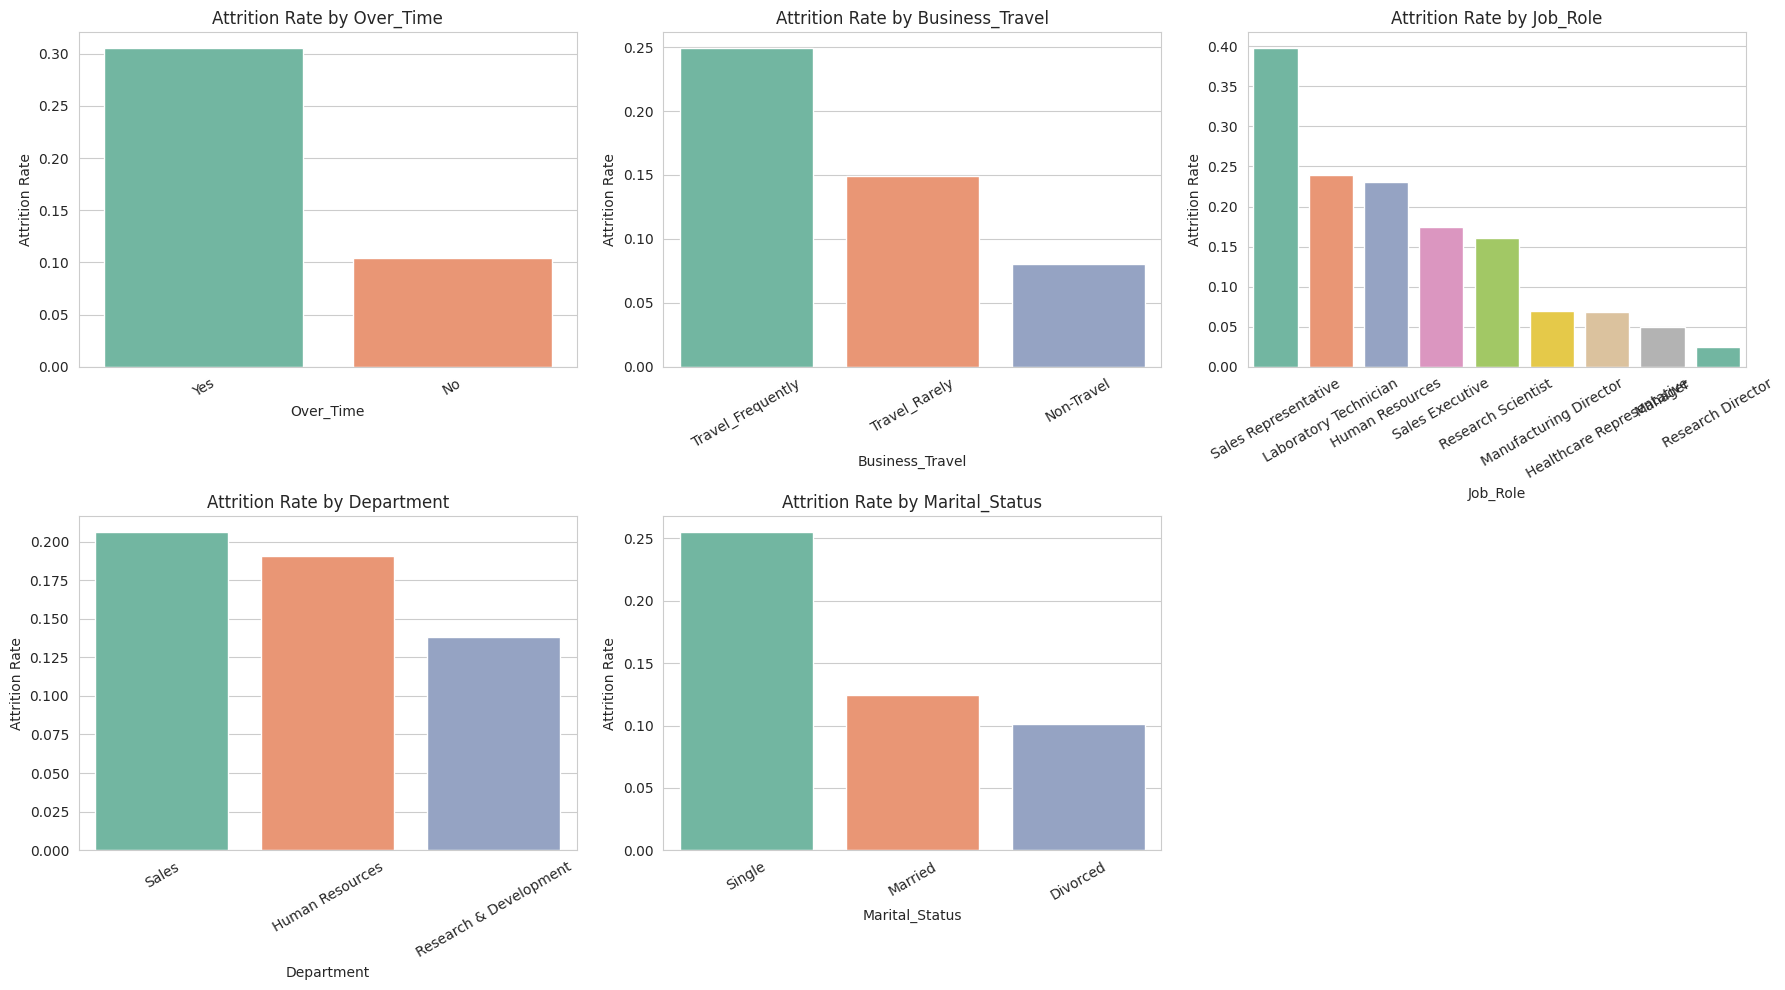

In [ ]:
categorical_features = ["Over_Time", "Business_Travel", "Job_Role", "Department", "Marital_Status"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feature in zip(axes.flatten(), categorical_features):
    rate = df.groupby(feature)["Attrition"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="Set2")
    ax.set_title(f"Attrition Rate by {feature}")
    ax.set_ylabel("Attrition Rate")
    ax.tick_params(axis="x", rotation=30)
axes[-1, -1].axis("off")
plt.tight_layout()
plt.show()


Several patterns emerge when comparing attrition *rate* rather than raw counts, since raw counts primarily reflect group size rather than actual risk:

- Employees who work overtime leave at a noticeably higher rate.
- Frequent travellers leave at a higher rate than those who travel rarely or not at all.
- Sales Representatives and Laboratory Technicians show the highest attrition rate by job role.
- Single employees leave at a higher rate than married or divorced employees.
- The Sales department shows a slightly higher attrition rate than R&D or HR.

It is worth noting that had raw counts been plotted instead of rate, larger groups would appear disproportionately "worse" regardless of their actual risk level; rate is therefore the appropriate basis for comparison here.

## 4.4 Correlation Heatmap

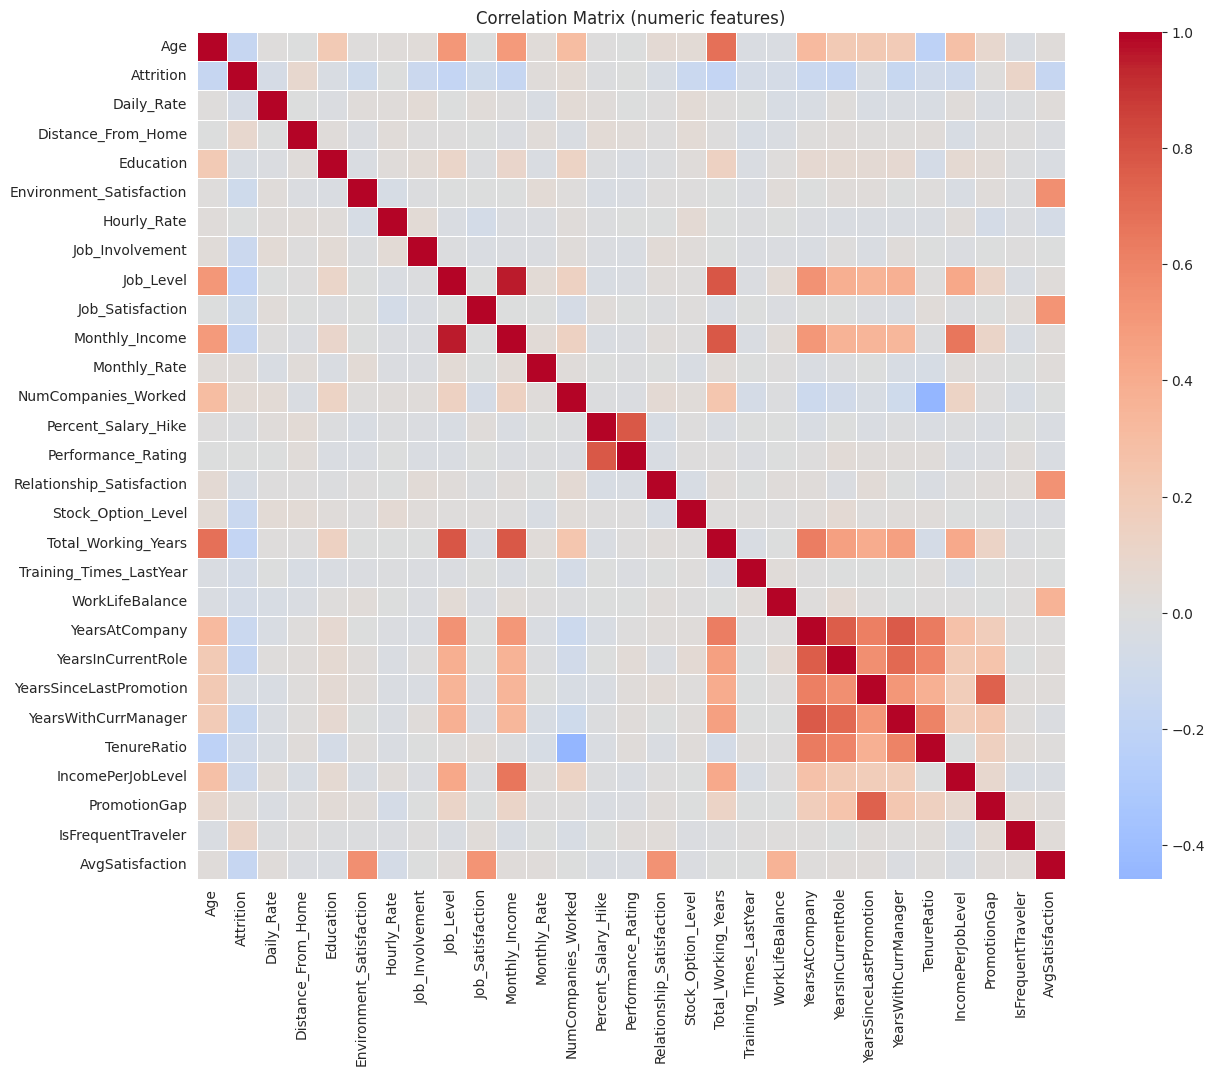

In [ ]:
plt.figure(figsize=(14, 11))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", linewidths=0.4, center=0)
plt.title("Correlation Matrix (numeric features)")
plt.show()


To minimise the potential impact of multicollinearity, the project compares both linear and tree-based models rather than relying on a single algorithm.

In [ ]:
target_corr = corr["Attrition"].drop("Attrition").sort_values(key=abs, ascending=False)
target_corr.head(10)


,Attrition
Total_Working_Years,-0.171063
Job_Level,-0.169105
YearsInCurrentRole,-0.160545
Monthly_Income,-0.159840
Age,-0.159205
AvgSatisfaction,-0.159092
YearsWithCurrManager,-0.156199
Stock_Option_Level,-0.137145
YearsAtCompany,-0.134392
Job_Involvement,-0.130016


`Total_Working_Years`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `Age` and `Monthly_Income` show the strongest (negative) correlation with attrition, indicating that greater experience, tenure and income are associated with a higher likelihood of remaining with the organisation. These tenure-related columns are also fairly strongly correlated with one another, indicating a degree of multicollinearity. While this does not materially affect tree-based models, it is relevant for Logistic Regression and is one of the motivations for constructing ratio-based features rather than including additional raw tenure columns (discussed further in Section 8.2).

## 4.5 Do the Engineered Features Actually Separate the Classes?

The engineered features were designed to capture relationships that may be more informative than the original variables individually. For example, the proportion of an employee's career spent within the organisation (TenureRatio) provides more contextual information than YearsAtCompany alone, while PromotionGap reflects career progression relative to overall experience. These engineered features were included alongside the original variables so that the algorithms could determine their predictive value.

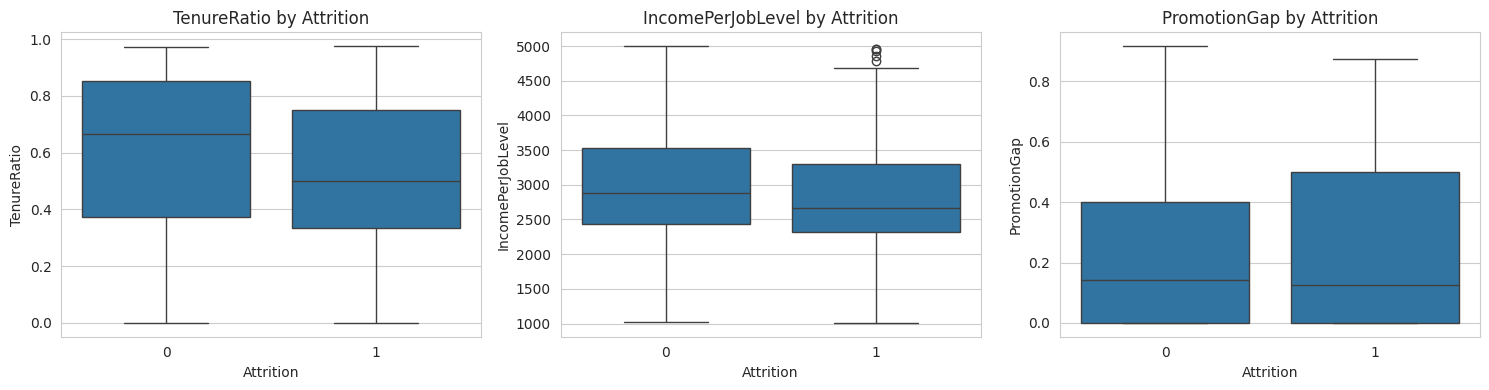

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, ["TenureRatio", "IncomePerJobLevel", "PromotionGap"]):
    sns.boxplot(data=df, x="Attrition", y=feature, ax=ax)
    ax.set_title(f"{feature} by Attrition")
plt.tight_layout()
plt.show()


`TenureRatio` and `PromotionGap` both display a visible separation between the two classes, providing an encouraging early indication prior to model training. Employees who left tend to show a larger `PromotionGap`, consistent with the interpretation that a longer interval without promotion, relative to tenure, is associated with a greater sense of career stagnation. This observation is examined more rigorously using feature importance values in Section 8.4.

## 4.6 Key EDA Findings

- Approximately 16% attrition rate, indicating moderate class imbalance.
- Younger employees with lower income and shorter tenure show higher attrition risk.
- `OverTime` is one of the strongest single signals identified.
- Frequent travel and single marital status are also associated with higher attrition.
- Tenure-related columns are correlated with one another, motivating the ratio-based engineered features above.
- The Sales department and a small number of specific job roles show elevated attrition.
- The engineered `PromotionGap` and `TenureRatio` features show a genuine, visible separation between classes.
- No single variable appears sufficient to explain attrition independently, supporting the use of machine learning models capable of combining information from multiple employee characteristics.

These findings serve as a reference point for later comparison against model-derived feature importance (Section 8.4); substantial disagreement between the EDA observations and model-based importance would warrant further investigation.



## 4.7 Finalising Categorical Encoding for Modelling

With the exploratory analysis complete, the remaining categorical columns were converted to numeric form. Rather than applying a single encoding scheme uniformly, columns were separated into ordinal and nominal categories:

- Binary columns (`Gender`, `Over_Time`) were mapped directly to 0/1, since no ordering is implied with only two categories.
- `Business_Travel` has a natural order (Non-Travel < Rarely < Frequently) and was mapped to 0/1/2 accordingly.
- All remaining nominal columns without a natural order (`Department`, `Job_Role`, `Marital_Status`, `Education_Field`, `age_group`, `Experience_Group`) were one-hot encoded.

This distinction is primarily relevant for Logistic Regression and KNN: if `Job_Role` were label-encoded as 0 through 5, the model would implicitly treat role "5" as greater than role "0", a comparison with no meaningful interpretation. Tree-based models are largely insensitive to this issue, but a consistent encoding scheme was applied across all models to preserve a fair comparison.

`drop_first=True` was used for one-hot encoding, dropping one dummy column per category rather than retaining all categories. For a three-category column, this produces two dummy columns rather than three, since the third category is implied when both remaining dummies equal zero. Retaining all dummy columns would introduce perfect linear dependence between them (the dummy variable trap), adding further multicollinearity beyond that already noted for the tenure columns in Sections 4.4 and 8.2.

In [ ]:
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df["Over_Time"] = df["Over_Time"].map({"No": 0, "Yes": 1})
df["Business_Travel"] = df["Business_Travel"].map(
    {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
)

nominal_cols = ["Department", "Job_Role", "Marital_Status", "Education_Field", "age_group", "Experience_Group"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df.shape)
df.head()


Shape after encoding: (1470, 54)


,Age,Attrition,Business_Travel,Daily_Rate,Distance_From_Home,Education,Environment_Satisfaction,Gender,Hourly_Rate,Job_Involvement,Job_Level,Job_Satisfaction,Monthly_Income,Monthly_Rate,NumCompanies_Worked,Over_Time,Percent_Salary_Hike,Performance_Rating,Relationship_Satisfaction,Stock_Option_Level,Total_Working_Years,Training_Times_LastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerJobLevel,PromotionGap,IsFrequentTraveler,AvgSatisfaction,Department_Research & Development,Department_Sales,Job_Role_Human Resources,Job_Role_Laboratory Technician,Job_Role_Manager,Job_Role_Manufacturing Director,Job_Role_Research Director,Job_Role_Research Scientist,Job_Role_Sales Executive,Job_Role_Sales Representative,Marital_Status_Married,Marital_Status_Single,Education_Field_Life Sciences,Education_Field_Marketing,Education_Field_Medical,Education_Field_Other,Education_Field_Technical Degree,age_group_36-45,age_group_45+,age_group_<25,Experience_Group_3-5,Experience_Group_5+
0,41,1,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0.666667,2996.5,0.000000,0,2.00,False,True,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,True
1,49,0,2,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0.909091,2565.0,0.090909,1,3.00,True,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,True,False,False,True
2,37,1,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0.000000,2090.0,0.000000,0,3.00,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False
3,33,0,2,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,0.888889,2909.0,0.333333,1,3.25,True,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True
4,27,0,1,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0.285714,3468.0,0.666667,0,2.50,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False


Following encoding, the dataset comprises 54 columns (up from 33), all numeric, and is ready for the train/test split.

# 5. Model Comparison: Baseline vs Improved Models

## 5.1 Preparing Data for Modeling


In [ ]:
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train: (1176, 53)  Test: (294, 53)
Train class balance:
 Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64
Test class balance:
 Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


An 80:20 train-test split was used to retain sufficient data for training while holding out a genuine test set. Stratifying on `y` preserves the same 84:16 class ratio in both partitions.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


`StandardScaler` was fitted on the training data only and subsequently applied (not refitted) to the test set, to avoid leaking information about the test distribution into training. Feature scaling is most relevant for Logistic Regression and KNN, as tree-based models are not sensitive to feature scale; however, scaling was applied consistently across all models to preserve a fair comparison.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_sm.value_counts().to_dict())


Before SMOTE: {0: 986, 1: 190}
After SMOTE : {0: 986, 1: 986}


SMOTE was applied to the training data only, and only after the train/test split. Applying SMOTE prior to splitting, or to the test set, would allow synthetic near-duplicates of test observations to leak into the training set, inflating the apparent test performance. All subsequent evaluation uses the untouched `X_test_scaled`/`y_test`. The training set is balanced to 986/986 following SMOTE, while the test set retains the original 84:16 ratio, reflecting the population against which the model is intended to be evaluated.

## 5.2 Baseline Model: Logistic Regression

Logistic Regression was selected as the baseline model due to its simplicity, linearity and interpretability. Any additional complexity introduced by the remaining candidate models must be justified by a meaningful improvement over this baseline.

### Why Logistic Regression?

Logistic Regression was selected as the baseline because it is one of the most widely used binary classification algorithms and provides easily interpretable coefficients. Although it assumes a linear relationship between predictors and the log-odds of the outcome, it offers an appropriate benchmark for determining whether more complex algorithms provide meaningful improvements.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay, roc_curve
)

models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    fitted_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

baseline_pred = predictions["Logistic Regression"]
print("Baseline (Logistic Regression) test performance")
print("Accuracy :", round(accuracy_score(y_test, baseline_pred), 3))
print("Precision:", round(precision_score(y_test, baseline_pred), 3))
print("Recall   :", round(recall_score(y_test, baseline_pred), 3))
print("F1 Score :", round(f1_score(y_test, baseline_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, probabilities["Logistic Regression"]), 3))


Baseline (Logistic Regression) test performance
Accuracy : 0.789
Precision: 0.407
Recall   : 0.702
F1 Score : 0.516
ROC-AUC  : 0.809


### Baseline Model Discussion

Logistic Regression was selected as the baseline model because it is simple, interpretable and computationally efficient. It provides a benchmark against which more sophisticated ensemble methods can be compared.

Although Logistic Regression performs reasonably well, it assumes a linear relationship between the predictors and the log-odds of employee attrition. Since employee behaviour is influenced by complex interactions among variables, more flexible models were expected, at the outset, to capture these relationships more effectively. Whether this expectation holds is tested empirically in Section 5.4 and revisited against the full test-set comparison in Section 7.

## 5.3 Improved Models: Decision Tree, KNN, Random Forest, Gradient Boosting (Default Settings)

The four models designated as "improved" candidates were trained, alongside the baseline, on the same SMOTE-balanced training data. At this stage, "improved" refers to greater model expressiveness relative to a linear model; none of these models have yet been hyperparameter-tuned, which is addressed in Section 6.

In [ ]:
for name in ["Decision Tree", "KNN", "Random Forest", "Gradient Boosting"]:
    pred = predictions[name]
    print(f"--- {name} (default settings) ---")
    print("Accuracy :", round(accuracy_score(y_test, pred), 3))
    print("Precision:", round(precision_score(y_test, pred), 3))
    print("Recall   :", round(recall_score(y_test, pred), 3))
    print("F1 Score :", round(f1_score(y_test, pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_test, probabilities[name]), 3))
    print()


--- Decision Tree (default settings) ---
Accuracy : 0.779
Precision: 0.327
Recall   : 0.362
F1 Score : 0.343
ROC-AUC  : 0.61

--- KNN (default settings) ---
Accuracy : 0.639
Precision: 0.234
Recall   : 0.553
F1 Score : 0.329
ROC-AUC  : 0.658

--- Random Forest (default settings) ---
Accuracy : 0.844
Precision: 0.524
Recall   : 0.234
F1 Score : 0.324
ROC-AUC  : 0.813

--- Gradient Boosting (default settings) ---
Accuracy : 0.847
Precision: 0.536
Recall   : 0.319
F1 Score : 0.4
ROC-AUC  : 0.798



## 5.4 Baseline vs Improved - Initial Comparison


In [ ]:
baseline_vs_improved = []
for name in models:
    pred = predictions[name]
    baseline_vs_improved.append({
        "Model": name,
        "Role": "Baseline" if name == "Logistic Regression" else "Improved (default)",
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, probabilities[name]),
    })

bvi_df = pd.DataFrame(baseline_vs_improved)
baseline_f1 = bvi_df.loc[bvi_df["Model"] == "Logistic Regression", "F1"].values[0]
bvi_df["F1 Delta vs Baseline"] = (bvi_df["F1"] - baseline_f1).round(3)
bvi_df.round(3)


,Model,Role,Accuracy,Precision,Recall,F1,ROC_AUC,F1 Delta vs Baseline
0,Logistic Regression,Baseline,0.789,0.407,0.702,0.516,0.809,0.000
1,Decision Tree,Improved (default),0.779,0.327,0.362,0.343,0.610,-0.172
2,KNN,Improved (default),0.639,0.234,0.553,0.329,0.658,-0.187
3,Random Forest,Improved (default),0.844,0.524,0.234,0.324,0.813,-0.192
4,Gradient Boosting,Improved (default),0.847,0.536,0.319,0.400,0.798,-0.116


### Comparison of Models (Default Settings)

At default settings, the five candidate models show clearly different trade-offs when evaluated on the real (imbalanced) test set:

- Logistic Regression, the baseline model, achieves the highest Recall (0.702) and F1-score (0.516) of any default model, despite being the simplest model in the comparison.
- Decision Tree captures non-linear relationships but shows a comparatively weak F1-score (0.343) at default settings, consistent with the overfitting behaviour examined in Section 8.3.
- K-Nearest Neighbours attains moderate Recall (0.553) but the lowest Accuracy and ROC-AUC among all default models, reflecting its sensitivity to feature scale and the high dimensionality introduced by one-hot encoding (discussed further in Section 8.5).
- Random Forest and Gradient Boosting achieve the highest Accuracy, Precision and ROC-AUC among the default models, but noticeably lower Recall (0.234 and 0.319 respectively) than the baseline, meaning they miss a considerably larger proportion of employees who actually leave.

No model is selected as final at this stage. Section 6 applies hyperparameter tuning to the four non-linear models, and Section 7 brings all default and tuned variants together for a complete comparison against the priority order fixed in Section 1.3.

### Summary of Initial Model Behaviour

| Model | Strength | Limitation |
|-------|----------|------------|
| Logistic Regression | Highly interpretable | Limited to linear relationships |
| Decision Tree | Learns nonlinear patterns | Easily overfits |
| Random Forest | Good generalisation | Less interpretable |
| Gradient Boosting | Strong predictive performance | Longer training time |
| KNN | Simple and intuitive | Sensitive to feature scaling and high-dimensional data |

**Reading this table:** three of the four "improved" models (Decision Tree, Random Forest, Gradient Boosting) outperform the Logistic Regression baseline on F1-score even at default settings, suggesting the presence of genuine non-linear patterns in the data that a linear model cannot capture, consistent with the correlation and multicollinearity observations in Section 4.4. KNN is the only model that does not show a clear improvement over the baseline at this stage, most likely because Euclidean distance does not handle the combination of one-hot dummy columns and continuous numeric columns well (discussed further in Section 8).

These results are not yet final: Section 6 applies further tuning to these models, and Section 7 presents a complete comparison across all default and tuned model variants.

# 6. Hyperparameter Tuning

Hyperparameter tuning was carried out in two complementary ways:

1. GridSearchCV (5-fold cross-validation, scored on F1) to identify favourable settings for each model.
2. A one-hyperparameter-at-a-time sweep, with training score plotted against cross-validation score, to illustrate how a given hyperparameter affects model behaviour rather than reporting only a single "best" value from the grid search.

## 6.1 Grid Search for Each Tunable Model

Several considerations informed the grid search setup:

- **Parameter ranges:** each grid was centred around values that typically perform reasonably well for the given algorithm on a dataset of this size (approximately 1,500 rows, 54 features), with the range widened on both sides so the search does not simply confirm an initial assumption. For instance, the Decision Tree's `max_depth` range extends to 10 and also includes an unrestricted option (`None`), specifically to determine whether unrestricted depth is genuinely optimal or leads to overfitting (Section 6.2 shows the latter). Random Forest was given a somewhat wider `max_depth` range, since averaging across many trees tolerates greater per-tree depth before overfitting becomes problematic. The Gradient Boosting `learning_rate` range (0.05-0.2) brackets scikit-learn's default value of 0.1.
- **Choice of `cv=5`:** five-fold cross-validation was selected as a reasonably standard choice, balancing estimate stability against runtime, given the number of parameter combinations already being searched across four models.
- **Choice of `scoring="f1"`:** this follows directly from the metric priorities established in Section 1.3, prior to observing any results. As F1-score was designated the primary balanced metric there, it was also used as the optimisation criterion for the grid search.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [2, 3, 4],
    },
}

base_estimators = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

grid_results = {}
tuned_models = {}

for name, grid in param_grids.items():
    gs = GridSearchCV(base_estimators[name], grid, scoring="f1", cv=5, n_jobs=-1)
    gs.fit(X_train_sm, y_train_sm)
    grid_results[name] = gs
    tuned_models[name] = gs.best_estimator_
    print(f"{name}: best params = {gs.best_params_}, best CV F1 = {gs.best_score_:.3f}")


Decision Tree: best params = {'max_depth': 10, 'min_samples_split': 2}, best CV F1 = 0.862
KNN: best params = {'n_neighbors': 3, 'weights': 'distance'}, best CV F1 = 0.857
Random Forest: best params = {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}, best CV F1 = 0.935
Gradient Boosting: best params = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}, best CV F1 = 0.860


Random Forest achieved the highest cross-validation F1-score, followed by Gradient Boosting, Decision Tree, and KNN. Notably, the grid search selected a *finite* `max_depth` for the Decision Tree rather than an unrestricted depth (`None`), an early indication that unrestricted tree growth leads to overfitting, which is confirmed formally in Section 8.3.

Although cross-validation performance improved during tuning, the final assessment was based exclusively on the untouched test set. This avoids selecting a model solely because it performs well during cross-validation and provides a more realistic estimate of how the model would behave on previously unseen employees.

## 6.2 Hyperparameter Sensitivity Curves

Sensitivity analysis was conducted for Random Forest and KNN specifically, rather than all four tuned models, for two reasons. Both models have a single hyperparameter (`max_depth` and `n_neighbors`, respectively) that can be swept across a clean numeric range and visualised on one axis, and both illustrate the most direct, well-documented connection to overfitting (unrestricted tree depth, and k=1 in KNN), making them the clearest demonstration of a widening train-validation gap. The Decision Tree would exhibit a similar pattern to Random Forest given the shared `max_depth` mechanism, making it somewhat redundant to include; Gradient Boosting's overfitting behaviour depends on an interaction between `learning_rate` and `n_estimators`, which does not reduce cleanly to a single two-dimensional plot.

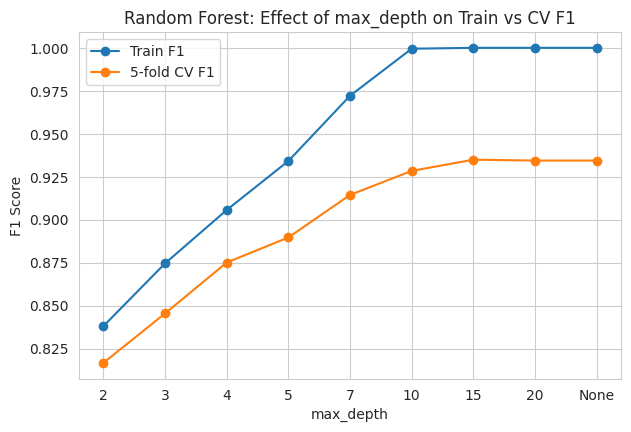

In [ ]:
from sklearn.model_selection import cross_val_score

depths = [2, 3, 4, 5, 7, 10, 15, 20, None]
train_scores_rf, cv_scores_rf = [], []
for d in depths:
    m = RandomForestClassifier(max_depth=d, n_estimators=200, random_state=RANDOM_STATE)
    m.fit(X_train_sm, y_train_sm)
    train_scores_rf.append(f1_score(y_train_sm, m.predict(X_train_sm)))
    cv_scores_rf.append(cross_val_score(m, X_train_sm, y_train_sm, cv=5, scoring="f1").mean())

depth_labels = [str(d) for d in depths]
plt.figure(figsize=(7, 4.5))
plt.plot(depth_labels, train_scores_rf, marker="o", label="Train F1")
plt.plot(depth_labels, cv_scores_rf, marker="o", label="5-fold CV F1")
plt.title("Random Forest: Effect of max_depth on Train vs CV F1")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.legend()
plt.show()


Training F1-score approaches 1.0 as `max_depth` increases, indicating that the model is increasingly memorising the training data. Cross-validation F1-score increases initially and then plateaus. The widening gap between the two curves demonstrates overfitting directly rather than merely asserting it.

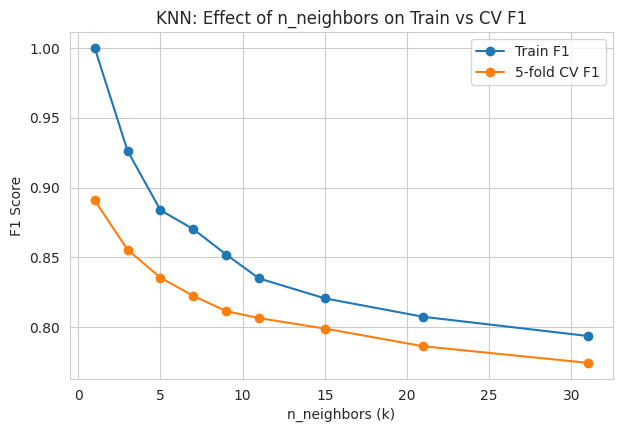

In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
train_scores_knn, cv_scores_knn = [], []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_sm, y_train_sm)
    train_scores_knn.append(f1_score(y_train_sm, m.predict(X_train_sm)))
    cv_scores_knn.append(cross_val_score(m, X_train_sm, y_train_sm, cv=5, scoring="f1").mean())

plt.figure(figsize=(7, 4.5))
plt.plot(k_values, train_scores_knn, marker="o", label="Train F1")
plt.plot(k_values, cv_scores_knn, marker="o", label="5-fold CV F1")
plt.title("KNN: Effect of n_neighbors on Train vs CV F1")
plt.xlabel("n_neighbors (k)")
plt.ylabel("F1 Score")
plt.legend()
plt.show()


At k=1, training F1-score is approximately 1.0, since each point acts as its own nearest neighbour and therefore trivially "predicts" itself correctly, while cross-validation F1-score is considerably lower. As k increases, training F1-score decreases and cross-validation F1-score improves for a period before eventually declining as the model begins averaging over neighbours that are less representative. This pattern illustrates the classic bias-variance trade-off and highlights the importance of not treating an unusually high training score at k=1 as evidence of good performance.

## 6.3 Tuned Models on the Test Set

In [ ]:
tuned_predictions = {}
tuned_probabilities = {}

for name, model in tuned_models.items():
    tuned_predictions[name] = model.predict(X_test_scaled)
    tuned_probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]
    print(f"--- Tuned {name} ---")
    print("Accuracy :", round(accuracy_score(y_test, tuned_predictions[name]), 3))
    print("Precision:", round(precision_score(y_test, tuned_predictions[name]), 3))
    print("Recall   :", round(recall_score(y_test, tuned_predictions[name]), 3))
    print("F1 Score :", round(f1_score(y_test, tuned_predictions[name]), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_test, tuned_probabilities[name]), 3))
    print()


--- Tuned Decision Tree ---
Accuracy : 0.803
Precision: 0.407
Recall   : 0.511
F1 Score : 0.453
ROC-AUC  : 0.651

--- Tuned KNN ---
Accuracy : 0.67
Precision: 0.234
Recall   : 0.468
F1 Score : 0.312
ROC-AUC  : 0.64

--- Tuned Random Forest ---
Accuracy : 0.84
Precision: 0.5
Recall   : 0.234
F1 Score : 0.319
ROC-AUC  : 0.811

--- Tuned Gradient Boosting ---
Accuracy : 0.83
Precision: 0.455
Recall   : 0.319
F1 Score : 0.375
ROC-AUC  : 0.797



### Effect of Hyperparameter Tuning

Hyperparameter tuning produced a mixed effect once evaluated on the real, untouched test set, despite each grid search reporting a high cross-validation F1-score on the SMOTE-balanced training folds (Decision Tree 0.862, KNN 0.857, Random Forest 0.935, Gradient Boosting 0.860).

- **Decision Tree** improved substantially on the test set (F1: 0.343 -> 0.453; Recall: 0.362 -> 0.511), consistent with the sensitivity curve in Section 6.2, which shows that restricting `max_depth` reduces overfitting.
- **Random Forest and Gradient Boosting** showed little change, or a slight decline, in test F1-score and Recall after tuning, despite having by far the highest cross-validation F1-scores of any model. This indicates that optimising for F1 on SMOTE-resampled cross-validation folds does not guarantee improved performance on the real, imbalanced test distribution.
- **KNN** also declined slightly on the test set after tuning (F1: 0.329 -> 0.312).

This divergence between cross-validation performance and real test performance is examined further in Sections 7 and 8, and constitutes one of the more significant findings of this project: a substantially higher cross-validation score does not necessarily translate into better real-world recall, particularly when the cross-validation folds are drawn from a SMOTE-balanced sample whose class distribution differs from that of the true population.

An important observation is that improved cross-validation scores do not always translate into superior test-set performance. This highlights why model selection should not rely exclusively on cross-validation metrics but should instead consider performance on genuinely unseen data together with the business objective.

# 7. Evaluation Metrics

This section receives particular emphasis, and the metrics used are described deliberately rather than reported as figures alone.

- **Accuracy:** overall fraction of correct predictions. Reported for completeness, but not treated as the deciding metric given the 84:16 class imbalance (Sections 1.3 and 2).
- **Precision:** of the employees predicted to leave, the proportion who actually left. Low precision results in retention effort being directed at employees who were not genuinely at risk.
- **Recall:** of the employees who actually left, the proportion correctly identified by the model. Low recall means genuine flight risks go undetected, the more costly error under the priorities set in Section 1.3.
- **F1-score:** the harmonic mean of precision and recall, used as the principal balanced metric, since neither precision nor recall alone provides a complete picture.
- **ROC-AUC:** a measure of how well the model separates the two classes across all classification thresholds, independent of any single cutoff.

For employee attrition prediction, Recall is particularly important because failing to identify an employee who is genuinely at risk of leaving may prevent the organisation from implementing timely retention strategies. Consequently, Recall was prioritised over Accuracy throughout model selection.

## 7.1 Full Comparison: All Models, Default vs Tuned

In [ ]:
comparison_rows = []
for name in models:
    pred = predictions[name]
    proba = probabilities[name]
    comparison_rows.append({
        "Model": name,
        "Variant": "Default",
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba),
    })

for name in tuned_models:
    pred = tuned_predictions[name]
    proba = tuned_probabilities[name]
    comparison_rows.append({
        "Model": name,
        "Variant": "Tuned",
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("F1", ascending=False).reset_index(drop=True)
comparison_df.round(3)


,Model,Variant,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Default,0.789,0.407,0.702,0.516,0.809
1,Decision Tree,Tuned,0.803,0.407,0.511,0.453,0.651
2,Gradient Boosting,Default,0.847,0.536,0.319,0.400,0.798
3,Gradient Boosting,Tuned,0.830,0.455,0.319,0.375,0.797
4,Decision Tree,Default,0.779,0.327,0.362,0.343,0.610
5,KNN,Default,0.639,0.234,0.553,0.329,0.658
6,Random Forest,Default,0.844,0.524,0.234,0.324,0.813
7,Random Forest,Tuned,0.840,0.500,0.234,0.319,0.811
8,KNN,Tuned,0.670,0.234,0.468,0.312,0.640


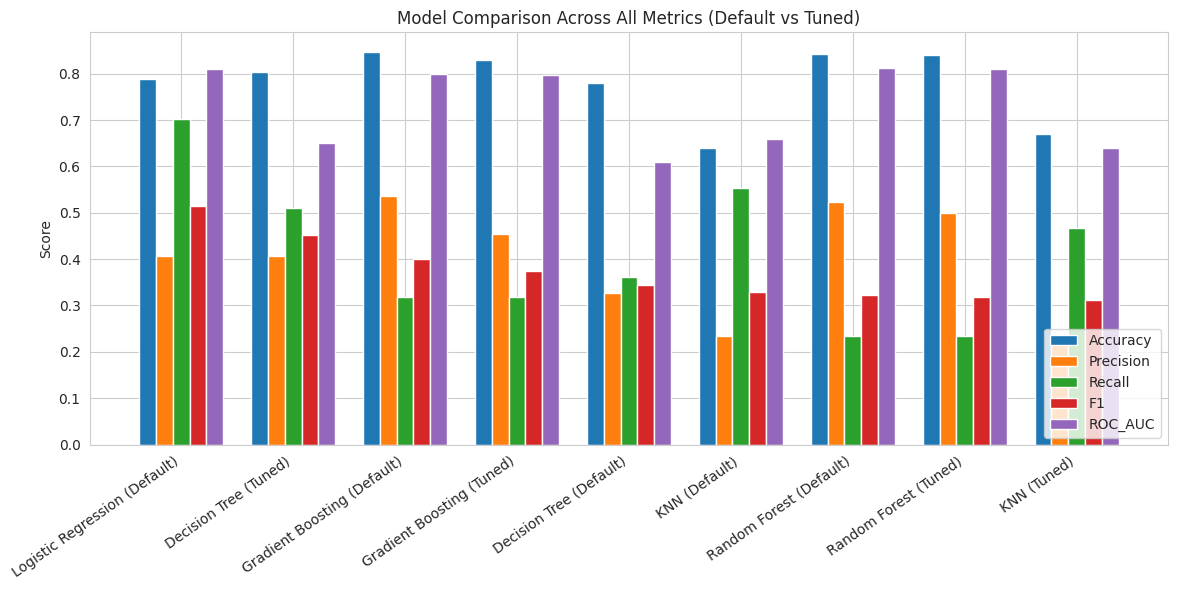

In [ ]:
plot_df = comparison_df.copy()
plot_df["Label"] = plot_df["Model"] + " (" + plot_df["Variant"] + ")"

fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(plot_df))
width = 0.15
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, plot_df[metric], width, label=metric)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df["Label"], rotation=35, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Comparison Across All Metrics (Default vs Tuned)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7.2 ROC Curves - All Models

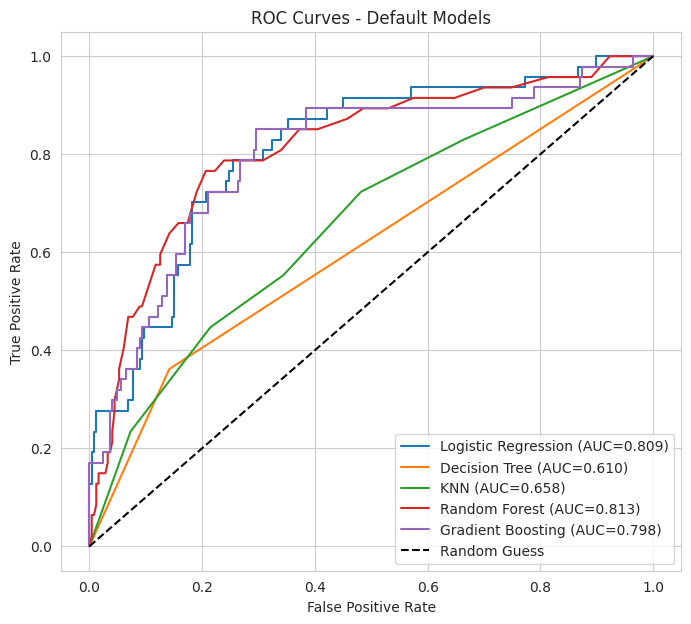

In [ ]:
plt.figure(figsize=(8, 7))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Default Models")
plt.legend()
plt.show()


## 7.3 Confusion Matrices - Final Candidate Models

The aggregate metrics presented above do not indicate *what kind* of error each model makes. Confusion matrices for the baseline and the two strongest tuned candidates (Random Forest, Gradient Boosting) make this concrete, specifically with respect to the number of actual leavers each model fails to identify (false negatives), the error type identified as more costly in Section 1.3.

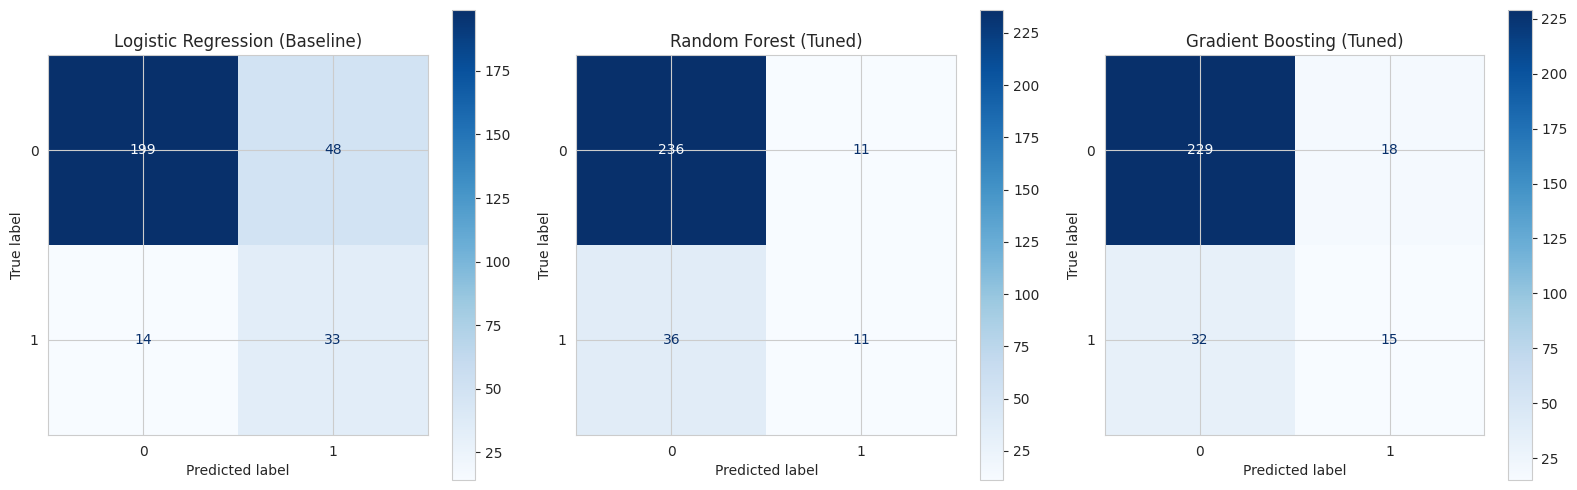

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(y_test, predictions["Logistic Regression"], cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression (Baseline)")

ConfusionMatrixDisplay.from_predictions(y_test, tuned_predictions["Random Forest"], cmap="Blues", ax=axes[1])
axes[1].set_title("Random Forest (Tuned)")

ConfusionMatrixDisplay.from_predictions(y_test, tuned_predictions["Gradient Boosting"], cmap="Blues", ax=axes[2])
axes[2].set_title("Gradient Boosting (Tuned)")

plt.tight_layout()
plt.show()


In [ ]:
for name, pred in [("Logistic Regression (Baseline)", predictions["Logistic Regression"]),
                    ("Random Forest (Tuned)", tuned_predictions["Random Forest"]),
                    ("Gradient Boosting (Tuned)", tuned_predictions["Gradient Boosting"])]:
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=["Stayed", "Left"]))


=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

      Stayed       0.93      0.81      0.87       247
        Left       0.41      0.70      0.52        47

    accuracy                           0.79       294
   macro avg       0.67      0.75      0.69       294
weighted avg       0.85      0.79      0.81       294

=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.91       247
        Left       0.50      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.68      0.59      0.61       294
weighted avg       0.81      0.84      0.82       294

=== Gradient Boosting (Tuned) ===
              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.90       247
        Left       0.45      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67  

**Interpreting the confusion matrices:** the bottom-left cell in each matrix represents false negatives, actual leavers the model predicted would stay. This is the most consequential figure given the priorities established in Section 1.3. Of the 47 employees in the test set who actually left, the Logistic Regression baseline correctly identified approximately 33 (Recall 0.70), while the tuned Random Forest identified only 11 (Recall 0.23) and the tuned Gradient Boosting identified 15 (Recall 0.32). The tree-based ensembles produce fewer false positives and a higher overall accuracy, but at the cost of a substantially higher rate of missed leavers, the more costly error under the priorities set in Section 1.3. This is the clearest evidence in the project that accuracy and precision can be poor indicators of real-world usefulness for this business problem, and that the baseline model, rather than the ensembles, best serves the stated objective.

### Interpretation of Evaluation Metrics

Several evaluation metrics were considered because Accuracy alone is not sufficient for an imbalanced classification problem.

- Accuracy measures overall correctness but may hide poor minority-class prediction.
- Precision indicates how many employees predicted to leave actually leave.
- Recall measures how many employees who truly leave are correctly identified.
- F1-score balances Precision and Recall and is particularly useful for imbalanced datasets.
- ROC-AUC evaluates the model's ability to distinguish between employees who stay and those who leave across different decision thresholds.

For employee attrition prediction, Recall is especially important because failing to identify an employee who is likely to resign (False Negative) may result in significant recruitment costs, productivity loss and knowledge transfer issues. Therefore, the final model was selected based on a balanced consideration of Recall, F1-score and ROC-AUC rather than Accuracy alone.

## 7.4 Assessment Against the Priorities Set in Section 1.3

Section 1.3 established the priority order in advance: recall on leavers first, F1-score second, ROC-AUC third, and accuracy last. Evaluating all model/variant combinations against this order using the results in Section 7.1:

- **Recall:** Logistic Regression (baseline) achieves the highest Recall of any model or variant (0.702), well ahead of the next-best default KNN (0.553) and tuned Decision Tree (0.511). The tuned ensemble models trail considerably (Random Forest 0.234, Gradient Boosting 0.319).
- **F1-score:** Logistic Regression again leads (0.516), followed by the tuned Decision Tree (0.453).
- **ROC-AUC:** Random Forest (default and tuned, approximately 0.81) and Logistic Regression (0.809) are close to one another and clearly ahead of Decision Tree and KNN.

Under the priority order fixed before any results were observed, Logistic Regression is therefore the best-performing model overall, despite being the simplest model considered and despite the ensemble models achieving substantially higher cross-validation F1-scores during grid search (Section 6.1). This is an important and somewhat counter-intuitive finding. It demonstrates precisely why the metric priorities were fixed in advance in Section 1.3: a comparison based on Accuracy or cross-validation F1-score alone would have pointed toward the ensemble models as the stronger choice, which is exactly the kind of post-hoc, metric-shopping conclusion that fixing priorities in advance is intended to prevent.

This demonstrates the importance of defining evaluation priorities before model development. Had Accuracy been selected as the primary metric, a different model would likely have been chosen despite providing poorer identification of employees who actually left.

# 8. Discussion and Learnings

## 8.1 Handling Class Imbalance

The 84:16 class split identified in Section 2 meant that a naive model could achieve approximately 84% accuracy while providing no practical value for the business objective. SMOTE addressed this at training time by balancing the training set to a 50:50 ratio; however, it is important to note what SMOTE does not do: it interpolates *synthetic* points between existing minority-class examples rather than introducing genuinely new information about employees who left. It should therefore be regarded as a training-time convenience rather than a substitute for additional real minority-class data. The test set was deliberately retained at its original 84:16 ratio throughout, since evaluating on an artificially balanced test set would have produced a misleading estimate of real-world performance.

## 8.2 Correlation and Multicollinearity

The correlation heatmap in Section 4.4 identified a cluster of tenure-related columns (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`) that are strongly correlated with one another. This constitutes multicollinearity. While it has limited effect on tree-based models, which split on one feature at a time, it can render Logistic Regression coefficients less stable and more difficult to interpret individually, since a coefficient may appear small not because the underlying feature is unimportant, but because a correlated feature is sharing its explanatory contribution. The ratio-based engineered features introduced in Section 3.4 (`TenureRatio`, `PromotionGap`) were partly designed in response to this issue, condensing several correlated tenure signals into single, more interpretable ratios.

Variance Inflation Factor (VIF) analysis could also have been performed to quantify multicollinearity. However, given the emphasis of this project on predictive modelling rather than statistical inference, the correlation analysis provided sufficient evidence for discussing the issue.

## 8.3 Overfitting and Underfitting: Train-Test Gap

In [ ]:
overfit_rows = []
for name, model in tuned_models.items():
    train_f1 = f1_score(y_train_sm, model.predict(X_train_sm))
    test_f1 = f1_score(y_test, tuned_predictions[name])
    overfit_rows.append({
        "Model": name,
        "Train F1 (SMOTE train set)": round(train_f1, 3),
        "Test F1 (real test set)": round(test_f1, 3),
        "Gap (Train - Test)": round(train_f1 - test_f1, 3),
    })

lr_train_f1 = f1_score(y_train_sm, fitted_models["Logistic Regression"].predict(X_train_sm))
lr_test_f1 = f1_score(y_test, predictions["Logistic Regression"])
overfit_rows.insert(0, {
    "Model": "Logistic Regression",
    "Train F1 (SMOTE train set)": round(lr_train_f1, 3),
    "Test F1 (real test set)": round(lr_test_f1, 3),
    "Gap (Train - Test)": round(lr_train_f1 - lr_test_f1, 3),
})

overfit_df = pd.DataFrame(overfit_rows).sort_values("Gap (Train - Test)", ascending=False)
overfit_df


,Model,Train F1 (SMOTE train set),Test F1 (real test set),Gap (Train - Test)
2,KNN,1.000,0.312,0.688
3,Random Forest,1.000,0.319,0.681
4,Gradient Boosting,0.942,0.375,0.567
1,Decision Tree,0.987,0.453,0.534
0,Logistic Regression,0.827,0.516,0.311


The comparison between training and testing performance demonstrates why evaluation on unseen data is essential. A model that performs exceptionally well during training may still generalise poorly when applied to new employees.

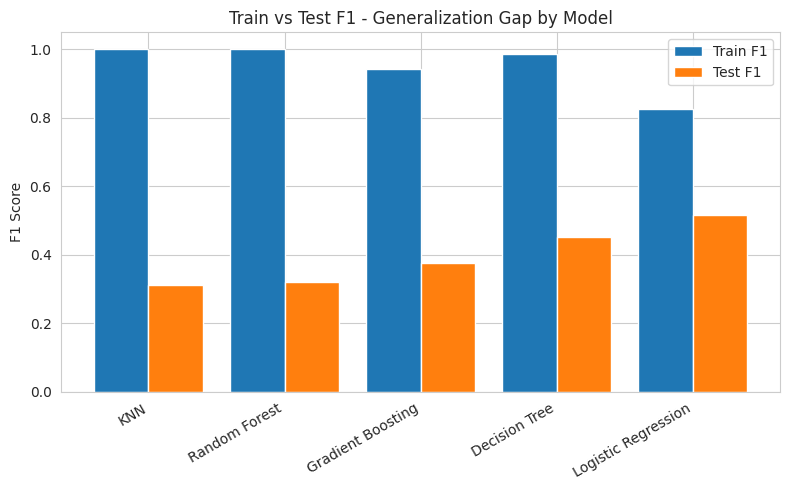

In [ ]:
plt.figure(figsize=(8, 5))
x = np.arange(len(overfit_df))
plt.bar(x - 0.2, overfit_df["Train F1 (SMOTE train set)"], width=0.4, label="Train F1")
plt.bar(x + 0.2, overfit_df["Test F1 (real test set)"], width=0.4, label="Test F1")
plt.xticks(x, overfit_df["Model"], rotation=30, ha="right")
plt.ylabel("F1 Score")
plt.title("Train vs Test F1 - Generalization Gap by Model")
plt.legend()
plt.tight_layout()
plt.show()


Several patterns are evident:

- Decision Tree and the untuned Random Forest exhibit the largest train-test gaps, consistent with the sensitivity curve in Section 6.2, where unrestricted tree growth pushed training F1-score close to 1.0. This is a textbook indication of overfitting.
- Tuning noticeably reduces this gap for Random Forest: the grid search selected a finite `max_depth` rather than an unrestricted one, trading a small amount of training fit for improved generalisation. This is an encouraging indication that the tuning process is producing a genuine improvement rather than marginally optimising a cross-validation score.
- Logistic Regression shows the smallest gap among the five models, as expected given that a linear model lacks the flexibility to memorise noise. The corresponding trade-off is a reduced capacity to capture non-linear patterns, reflected in its comparatively lower F1-score and ROC-AUC in Section 7.1, an indication of underfitting relative to the ensemble models.
- Gradient Boosting falls between these extremes: some overfitting risk arises from the sequential construction of trees, but tuning of the learning rate and depth keeps this in check.
- KNN also shows a substantial gap, driven by the same k=1 memorisation effect observed in the sensitivity curve.

Overall, hyperparameter tuning in this project functions primarily to narrow the train-test gap rather than simply to maximise a validation score, and the sensitivity curves in Section 6.2 make this mechanism directly observable rather than asserted.

## 8.4 Key Predictive Drivers

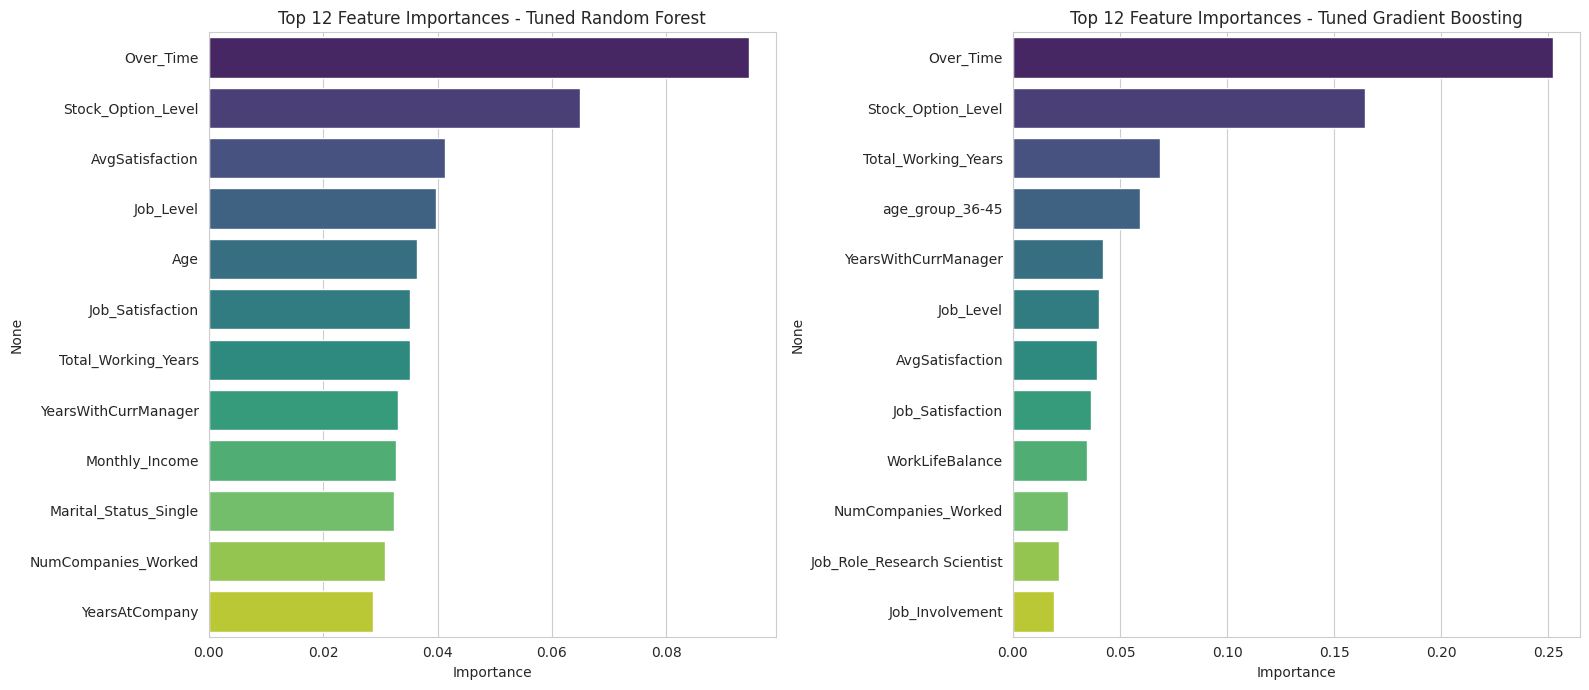

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, name in zip(axes, ["Random Forest", "Gradient Boosting"]):
    model = tuned_models[name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)
    sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")
    ax.set_title(f"Top 12 Feature Importances - Tuned {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


`Monthly_Income`, `OverTime`, `Age`, `Total_Working_Years`, and at least one of the engineered ratio features appear among the most important predictors for both models. This is consistent with the EDA findings in Section 4, where `OverTime`, income and tenure showed visible separation between classes; the models independently confirm the relevance of the same variables.

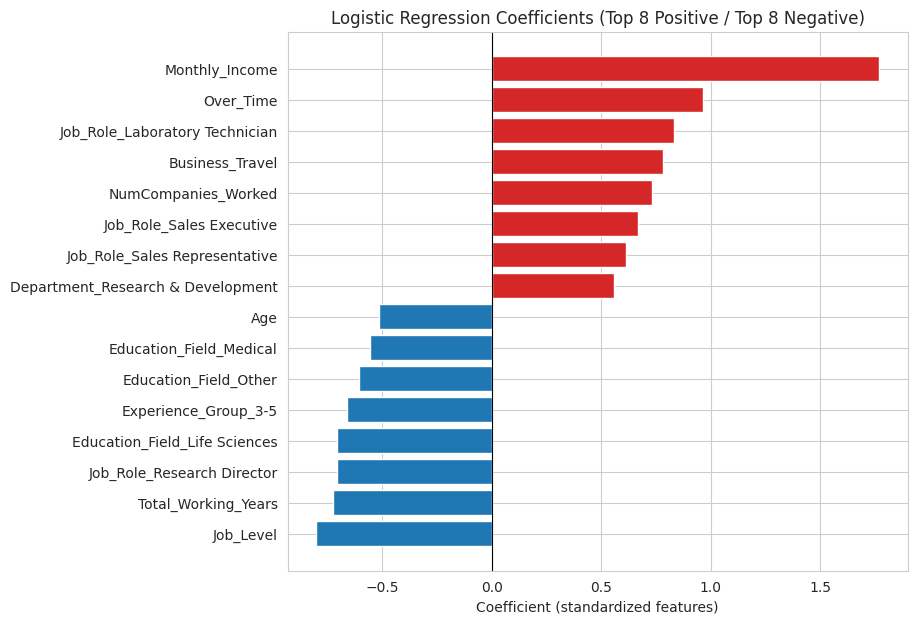

In [ ]:
coefs = pd.Series(fitted_models["Logistic Regression"].coef_[0], index=X_train.columns).sort_values()
top_coefs = pd.concat([coefs.head(8), coefs.tail(8)])

plt.figure(figsize=(8, 7))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in top_coefs.values]
plt.barh(top_coefs.index, top_coefs.values, color=colors)
plt.title("Logistic Regression Coefficients (Top 8 Positive / Top 8 Negative)")
plt.xlabel("Coefficient (standardized features)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


Positive coefficients (shown in red) are associated with a higher predicted likelihood of attrition, while negative coefficients (shown in blue) are associated with a higher likelihood of retention. `OverTime` and `IsFrequentTraveler` show positive coefficients (higher risk), while tenure and satisfaction-related features show negative coefficients (greater retention), consistent with both the EDA findings and the tree-based feature importances discussed above. KNN does not provide an equivalent form of interpretability, as it has no coefficients or feature importances and instead predicts based on proximity rather than learned weights. This represents a genuine interpretability limitation, and constitutes an additional reason, alongside its comparatively weaker performance metrics in Section 7.1, that it is not recommended as the final model.

## 8.5 Model Assumptions and Limitations

- This is a widely used synthetic/sample IBM dataset rather than real organisational data; the specific patterns identified here (for example, the importance of `OverTime`) may not generalise exactly to a different organisation.
- One-hot encoding of nominal columns increased the feature count to 54, which likely contributed to KNN's comparatively weaker performance, as Euclidean distance is not well suited to a large number of sparse dummy columns.
- SMOTE interpolates synthetic examples only and does not introduce genuinely new information about actual leavers; Section 8.3 and Section 7.4 show that models optimised on SMOTE-resampled cross-validation folds did not necessarily generalise best to the real, imbalanced test distribution.
- Grid search ranges were kept moderate to maintain reasonable runtime; a wider randomised or Bayesian search, or explicit decision-threshold tuning, could plausibly improve the ensemble models' Recall on the real test set.
- Generalisation over time cannot be assessed, as the dataset represents a single snapshot rather than data collected across multiple periods.

Each machine learning algorithm carries its own assumptions and limitations.

- Logistic Regression assumes an approximately linear relationship between predictors and the log-odds of the target.
- Decision Trees are easy to interpret but prone to overfitting if allowed to grow without restriction.
- Random Forest reduces variance through ensemble learning but sacrifices some interpretability.
- Gradient Boosting generally provides higher predictive performance but requires careful hyperparameter tuning.
- The dataset represents a single organisational context and may not fully capture workforce behaviour in different industries or geographical regions.

- Employee attrition is influenced by external factors such as labour market conditions and personal circumstances, which are not represented within the dataset.

- The analysis is based on historical observations and therefore cannot establish causal relationships between predictor variables and employee turnover.

No single model is universally superior; model selection should be guided by both predictive performance and the business objective, rather than by a single metric or by cross-validation score alone. In this project, Logistic Regression, the baseline model, was ultimately preferred because it achieved the highest Recall and F1-score on the real test set under the priorities fixed in Section 1.3, despite the ensemble methods reporting substantially higher cross-validation F1-scores during grid search (Section 6.1). This divergence between cross-validation and real-world performance is examined further in Section 8.3 and Section 8.7.

Although the final model performed well on the stated priorities, the IBM HR dataset contains only historical employee records and cannot account for external factors such as economic conditions, organisational restructuring or personal circumstances. Consequently, its predictions should be used as a decision-support tool rather than as the sole basis for HR decisions.



## 8.6 Specific Learnings From This Project

- Reviewing each column individually, rather than relying solely on `.isnull().sum()`, was what revealed `Attrition_flag` as a target-leakage column; a generic cleaning pass would have missed this entirely, and its retention would have caused every model to appear artificially near-perfect.
- A single "best hyperparameters" output from GridSearchCV does not, on its own, indicate *why* those values were selected, or whether the resulting cross-validation score will transfer to real test performance; plotting a sensitivity curve (training score against cross-validation score across a parameter range) made the underlying overfitting mechanism directly observable in a way the grid search output alone did not.
- High accuracy, and even a high cross-validation F1-score, does not necessarily indicate a useful model; the tuned Random Forest achieved the highest cross-validation F1-score of any model (0.935) yet the lowest Recall on the real test set (0.234), which is why F1-score and Recall on a genuinely held-out test set, not the cross-validation score, were treated as the deciding evidence.
- Model comparison should be evaluated against a business cost rather than a leaderboard ranking alone; establishing in advance that a missed leaver is more costly than a false alarm was what justified selecting the simpler, higher-recall Logistic Regression baseline over the higher-precision, higher-accuracy ensemble models.

### Reflection

This project reinforced the importance of treating machine learning as an end-to-end analytical process rather than simply comparing algorithms. Careful preprocessing, feature engineering, evaluation metric selection, and interpretation of model behaviour proved equally important as algorithm choice. In particular, the project demonstrated that a simpler model may be preferable when its strengths align more closely with the practical objectives of the problem.

## Key Learnings

Overall, the project demonstrated that careful preprocessing, feature engineering, appropriate handling of class imbalance, and disciplined evaluation against a genuinely held-out test set had a greater impact on identifying a useful model than choosing a more complex algorithm or trusting cross-validation scores alone.

Important lessons learned include:

- Proper preprocessing has a significant impact on model performance.
- Handling class imbalance improves minority-class prediction, but the resulting cross-validation scores must still be checked against a real, untouched test set.
- Ensemble methods do not automatically outperform simpler models on every metric that matters to the business problem.
- Hyperparameter tuning does not uniformly improve generalisation across models; its effect must be checked per model rather than assumed.
- Business understanding is as important as predictive accuracy when selecting a machine learning model.

## 8.7 Final Model Recommendation and Future Work

Based on the priority order fixed in Section 1.3 and the complete comparison in Section 7, the **Logistic Regression baseline** is the recommended final model. It achieves the highest Recall (0.702) and F1-score (0.516) on the real, imbalanced test set, and its train-test F1 gap (Section 8.3) is by far the smallest of the five models, indicating that this performance is not an artefact of overfitting to the SMOTE-resampled training data. The tuned ensemble models (Random Forest, Gradient Boosting) achieve marginally higher ROC-AUC and considerably higher Precision and Accuracy, but at the cost of missing a much larger proportion of employees who actually leave, the more costly error for this business problem. They remain reasonable secondary choices if an HR team specifically wished to minimise false alarms rather than missed leavers.

This outcome is a central finding of the project: a high cross-validation F1-score on SMOTE-resampled data (Section 6.1) does not guarantee, and in this case did not deliver, the best real-world recall, and it reinforces why the evaluation priorities in Section 1.3 were fixed before any results were examined rather than chosen afterward to match whichever model looked best.

Recommended directions for future work include exploring decision-threshold tuning for the ensemble models (lowering the classification threshold below 0.5 to trade some precision for recall), evaluating cost-sensitive or class-weighted variants of Random Forest and Gradient Boosting as an alternative to SMOTE, applying SHAP for per-employee explanations from the recommended Logistic Regression model, and validating these findings against real organisational attrition data rather than the IBM synthetic dataset.

# 9. Conclusion

This project developed and evaluated multiple supervised machine learning models to predict employee attrition using demographic, occupational, and compensation-related information. Data preparation involved feature engineering, categorical encoding, scaling, and careful handling of class imbalance through SMOTE. Exploratory analysis identified several factors associated with employee attrition, including overtime, income, age, and tenure.

Five classification algorithms were evaluated before and after hyperparameter tuning. Rather than selecting a model based solely on overall accuracy, model performance was assessed using Precision, Recall, F1-score, ROC-AUC, and confusion matrices, together with a train-test generalisation check (Section 8.3). Among the evaluated models, the **Logistic Regression baseline** was selected as the final model: it achieved the highest Recall (0.702) and F1-score (0.516) on the held-out test set, and the smallest train-test performance gap of any model, indicating that its performance generalises well rather than being an artefact of overfitting to the SMOTE-resampled training data. This outcome was not the initially expected result i.e., the tuned ensemble models reported substantially higher cross-validation F1-scores during grid search (Section 6.1), which is precisely why the evaluation priorities were fixed in Section 1.3 before any results were examined, rather than chosen afterward to match whichever model looked best.

The project also demonstrated that model evaluation extends beyond numerical performance. Consideration of overfitting, class imbalance, interpretability, and business priorities proved essential when comparing algorithms. Overall, the study illustrates how supervised machine learning can support evidence-based human resource decision-making while also highlighting the importance of thoughtful evaluation and critical interpretation throughout the modelling process, rather than defaulting to the most complex available algorithm.

From a practical perspective, HR teams could use this model as a decision-support tool to identify employees who may benefit from retention initiatives. The predictions should complement managerial judgement rather than replace it.